# Drug coverage & learnability — CTRPv2 × SCP542

Quantifies, **per drug**, how many cell lines have a measurement (coverage) and how much the
response actually varies across lines (variance) — the two things that decide whether a drug is
*learnable*. Then links coverage/variance to the trained model's per-drug performance ("does it
beat the per-drug-mean baseline?").

Why this matters: viability clusters near 1.0, so a drug is only learnable if it has (a) enough
cell lines screened against it, and (b) real spread in response. Low-coverage / low-variance drugs
are the ones no model can beat the baseline on.

In [1]:
from pathlib import Path
import glob, os
import numpy as np, pandas as pd, scanpy as sc
import matplotlib.pyplot as plt

TARGETS = Path('/Users/selin/Desktop/OncoTox/data/processed/scRNAseq_SCP542/hvg5000/'
               'SCP542_CCLE_scGPT_human_embeddings_with_targets.h5ad')
a = sc.read_h5ad(TARGETS, backed='r')
drugs = list(a.uns['ctrp_drugs'])
print(f'{len(drugs)} drugs, {a.n_obs} cells')

545 drugs, 53513 cells


## 1. Collapse to one row per cell line

The label is constant within a cell line (bulk value broadcast to its cells), so we take one
representative cell per line → a (cell line × drug) viability matrix.

In [2]:
cl = a.obs['Cell_line'].astype(str).values
M = np.asarray(a.obsm['M_ctrp']).astype(bool)          # observed mask (n_cells, 545)
Y = np.asarray(a.obsm['Y_ctrp'], dtype=float)          # viability, NaN/0 where missing

rep = pd.DataFrame({'cl': cl}).drop_duplicates('cl')   # first cell per line, preserves order
line_names = rep['cl'].values
rows = rep.index.values
M_line = M[rows]                                       # (n_lines, 545)
Y_line = np.where(M_line, Y[rows], np.nan)             # mask-truth: NaN where not screened

n_lines = len(line_names)
lines_with_any = int(M_line.any(1).sum())
print(f'{n_lines} unique SCP542 cell lines; {lines_with_any} overlap CTRPv2 (have >=1 drug label)')

198 unique SCP542 cell lines; 180 overlap CTRPv2 (have >=1 drug label)


## 2. Per-drug coverage (how many cell lines measured each drug)

In [3]:
cov = M_line.sum(0)                                     # lines per drug
resp_std = np.nanstd(Y_line, axis=0)                   # response spread across lines
resp_mean = np.nanmean(Y_line, axis=0)
drug_df = pd.DataFrame({
    'drug': drugs,
    'n_lines': cov,
    'pct_of_overlap': 100 * cov / lines_with_any,
    'resp_mean': resp_mean,
    'resp_std': resp_std,
}).sort_values('n_lines', ascending=False).reset_index(drop=True)

print('coverage summary (lines per drug):')
print(drug_df['n_lines'].describe()[['min','25%','50%','75%','max']].round(1).to_string())
print(f"\ndrugs measured on ALL {lines_with_any} overlapping lines: "
      f"{(cov == lines_with_any).sum()} / {len(drugs)}")
print(f"drugs measured on >=90% of overlapping lines: {(drug_df['pct_of_overlap']>=90).sum()}")
print(f"drugs measured on <50% of overlapping lines:  {(drug_df['pct_of_overlap']<50).sum()}")

coverage summary (lines per drug):
min     15.0
25%    151.0
50%    171.0
75%    174.0
max    179.0

drugs measured on ALL 180 overlapping lines: 0 / 545
drugs measured on >=90% of overlapping lines: 382
drugs measured on <50% of overlapping lines:  80


### Distribution of per-drug coverage

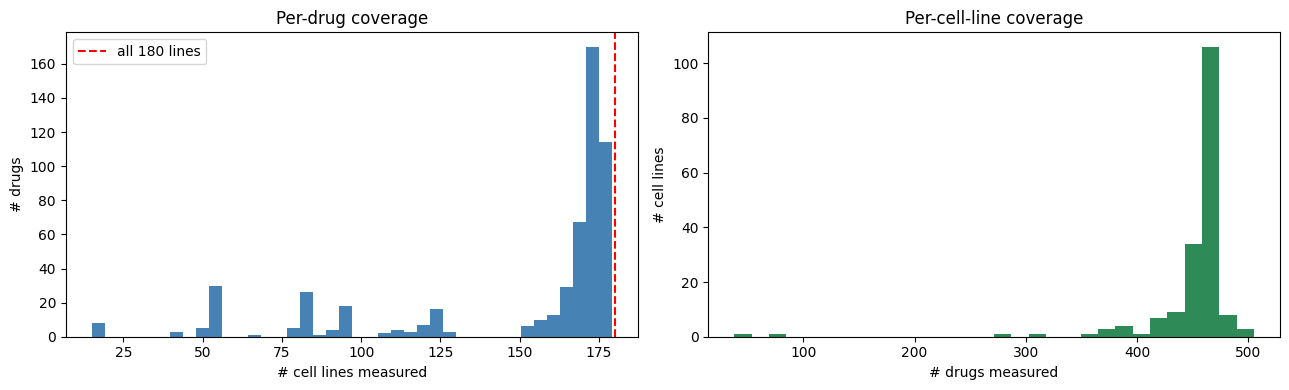

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(drug_df['n_lines'], bins=40, color='steelblue')
ax[0].axvline(lines_with_any, color='red', ls='--', label=f'all {lines_with_any} lines')
ax[0].set_xlabel('# cell lines measured'); ax[0].set_ylabel('# drugs'); ax[0].set_title('Per-drug coverage'); ax[0].legend()
ax[1].hist(M_line.sum(1)[M_line.any(1)], bins=30, color='seagreen')
ax[1].set_xlabel('# drugs measured'); ax[1].set_ylabel('# cell lines'); ax[1].set_title('Per-cell-line coverage')
plt.tight_layout(); plt.show()

### Most- and least-covered drugs

In [5]:
print('TOP 10 coverage:'); print(drug_df.head(10).to_string(index=False))
print('\nBOTTOM 10 coverage:'); print(drug_df.tail(10).to_string(index=False))

TOP 10 coverage:
         drug  n_lines  pct_of_overlap  resp_mean  resp_std
     snx-2112      179       99.444444   0.720657  0.169307
    ceranib-2      178       98.888889   0.777768  0.102221
     curcumin      178       98.888889   0.820567  0.072850
    nsc632839      178       98.888889   0.838148  0.087249
      osi-027      178       98.888889   0.810007  0.103320
  vincristine      178       98.888889   0.599117  0.200408
   decitabine      178       98.888889   0.959545  0.083563
    pazopanib      178       98.888889   0.906615  0.101629
   pha-793887      178       98.888889   0.817539  0.117471
brd-k63431240      178       98.888889   0.732459  0.094820

BOTTOM 10 coverage:
                         drug  n_lines  pct_of_overlap  resp_mean  resp_std
                brd-k09344309       41       22.777778   1.074937  0.093111
                  abiraterone       40       22.222222   1.002150  0.069242
                brd-k01737880       16        8.888889   0.926061  0.13049

## 3. Coverage vs response variance

Coverage alone isn't enough — a drug also needs **spread** in response to be learnable. High
coverage + high `resp_std` = easiest; low on either = hard.

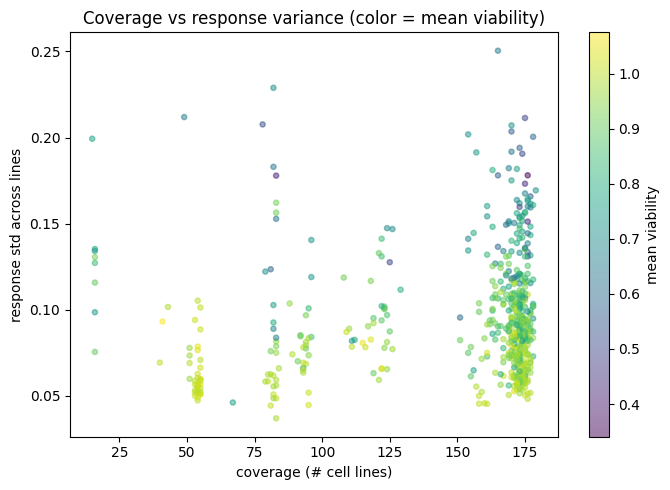

low-variance drugs (std < 0.05) — little to learn even if well covered: 14


In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
sc_ = ax.scatter(drug_df['n_lines'], drug_df['resp_std'], s=14, alpha=0.5, c=drug_df['resp_mean'], cmap='viridis')
ax.set_xlabel('coverage (# cell lines)'); ax.set_ylabel('response std across lines')
ax.set_title('Coverage vs response variance (color = mean viability)')
fig.colorbar(sc_, label='mean viability'); plt.tight_layout(); plt.show()
print('low-variance drugs (std < 0.05) — little to learn even if well covered:',
      int((drug_df['resp_std'] < 0.05).sum()))

## 4. Does coverage / variance predict model performance?

Merge with the latest multi-task run's `per_drug_results.csv` (per-drug `model_val_mse`,
`baseline_val_mse`, `delta`, `n_val`). `delta < 0` ⇒ the model beats the per-drug-mean baseline.

In [7]:
runs = sorted(glob.glob('/Users/selin/PycharmProjects/OncoTox/runs/*_all_drugs/per_drug_results.csv'), key=os.path.getmtime)
assert runs, 'no *_all_drugs run found — train a K=545 model first'
run_csv = runs[-1]
print('using', run_csv)
pdr = pd.read_csv(run_csv)
m = drug_df.merge(pdr, on='drug', how='inner')
m['beats'] = m['delta_model_minus_baseline'] < 0 if 'delta_model_minus_baseline' in m else (m['model_val_mse'] < m['baseline_val_mse'])
print(f"{m['beats'].sum()} / {len(m)} heads beat baseline in this run")

using /Users/selin/PycharmProjects/OncoTox/runs/20260614_205926_multitask_X_pca_all_drugs/per_drug_results.csv
196 / 545 heads beat baseline in this run


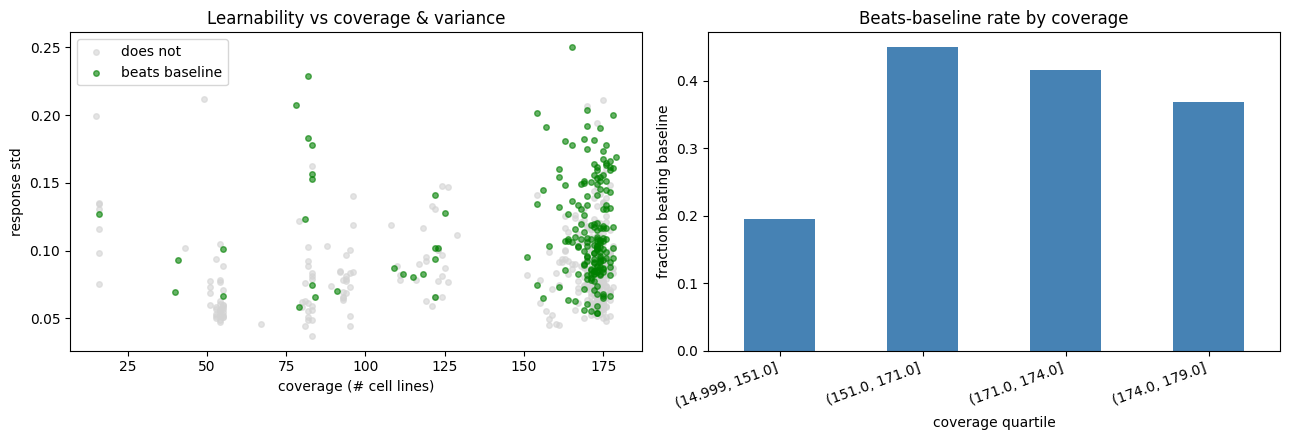

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for beats, sub in m.groupby('beats'):
    ax[0].scatter(sub['n_lines'], sub['resp_std'], s=16, alpha=0.6,
                  label='beats baseline' if beats else 'does not', color='green' if beats else 'lightgray')
ax[0].set_xlabel('coverage (# cell lines)'); ax[0].set_ylabel('response std'); ax[0].set_title('Learnability vs coverage & variance'); ax[0].legend()

# beats-baseline rate by coverage quartile
m['cov_bin'] = pd.qcut(m['n_lines'], 4, duplicates='drop')
rate = m.groupby('cov_bin')['beats'].mean()
rate.plot(kind='bar', ax=ax[1], color='steelblue')
ax[1].set_ylabel('fraction beating baseline'); ax[1].set_xlabel('coverage quartile'); ax[1].set_title('Beats-baseline rate by coverage')
plt.setp(ax[1].get_xticklabels(), rotation=20, ha='right'); plt.tight_layout(); plt.show()

## 5. Easiest vs hardest drugs to predict

In [9]:
easy = m.sort_values('delta_model_minus_baseline').head(10)[['drug','n_lines','resp_std','model_val_mse','baseline_val_mse','n_val']]
hard = m.sort_values('delta_model_minus_baseline', ascending=False).head(10)[['drug','n_lines','resp_std','model_val_mse','baseline_val_mse','n_val']]
print('EASIEST (largest model gain over baseline):'); print(easy.to_string(index=False))
print('\nHARDEST (model worse than baseline):'); print(hard.to_string(index=False))

EASIEST (largest model gain over baseline):
                            drug  n_lines  resp_std  model_val_mse  baseline_val_mse  n_val
                          gsk-j4       16  0.127143       0.000186          0.011351    221
                   brd-k09344309       41  0.093111       0.009965          0.015694   1279
                           qs-11       55  0.101253       0.008351          0.012296   2005
                    oligomycin a      165  0.250433       0.087044          0.090586   6144
                       docetaxel       78  0.207613       0.044063          0.047262   3272
                       nilotinib      175  0.116374       0.011495          0.013846   6816
  epigallocatechin-3-monogallate      168  0.108781       0.014364          0.016342   6816
                           ml312       55  0.066277       0.006343          0.008279   2005
                     gemcitabine      154  0.201814       0.029424          0.031124   5751
erlotinib:plx-4032 (2:1 mol/mol)    